In [16]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
import faiss
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

In [30]:
baseline_tfidf_precision = 0.70
baseline_tfidf_recall = 0.65
baseline_tfidf_f1 = 0.67
baseline_bert_precision = 0.92
baseline_bert_recall = 0.87
baseline_bert_f1 = 0.89


In [21]:
# --- Calculate Ground Truth using TF-IDF ---
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(freelancers['profile'])
Y = vectorizer.transform(projects['description'])
cosine_sim_ground = cosine_similarity(Y, X)
ground_truth_indices = np.argmax(cosine_sim_ground, axis=1)  # Index of max similarity
ground_truth = dict(zip(projects['id'], freelancers['id'][ground_truth_indices]))



In [22]:
X_pred = vectorizer.fit_transform(freelancers['profile'])
Y_pred = vectorizer.transform(projects['description'])
cosine_sim = cosine_similarity(Y_pred, X_pred)
tfidf_top_k = np.argsort(cosine_sim, axis=1)[:, ::-1][:, :3]  # Top-3 matches
tfidf_predicted = [freelancers['id'][idx[0]] for idx in tfidf_top_k]  

In [23]:
# --- MiniLM + FAISS ---
model = SentenceTransformer('all-MiniLM-L6-v2')
freelancer_embeddings = model.encode(freelancers['profile'].tolist())
project_embeddings = model.encode(projects['description'].tolist())
index = faiss.IndexFlatL2(freelancer_embeddings.shape[1])
index.add(freelancer_embeddings)
distances, indices = index.search(project_embeddings, 3)  # Top-3 matches
bert_predicted = [freelancers['id'][idx[0]] for idx in indices]

C:\Users\Siddhesh Patil\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [24]:
true_labels = [ground_truth[proj_id] for proj_id in projects['id']]


In [25]:
# TF-IDF evaluation
tfidf_preds_top_k = [[freelancers['id'][i] for i in row] for row in tfidf_top_k]
tfidf_correct = [1 if true in preds else 0 for true, preds in zip(true_labels, tfidf_preds_top_k)]
tfidf_precision = sum(tfidf_correct) / len(tfidf_correct)
tfidf_recall = tfidf_precision  # Simplified: one true match per project
tfidf_f1 = 2 * (tfidf_precision * tfidf_recall) / (tfidf_precision + tfidf_recall) if (tfidf_precision + tfidf_recall) > 0 else 0


In [26]:
# BERT evaluation
bert_preds_top_k = [[freelancers['id'][i] for i in row] for row in indices]
bert_correct = [1 if true in preds else 0 for true, preds in zip(true_labels, bert_preds_top_k)]
bert_precision = sum(bert_correct) / len(bert_correct)
bert_recall = bert_precision  # Simplified
bert_f1 = 2 * (bert_precision * bert_recall) / (bert_precision + bert_recall) if (bert_precision + bert_recall) > 0 else 0


In [32]:
print("Performance Metrics (Top-3 Matches)")
print("TF-IDF + Cosine Similarity:")
print(f"Precision: {baseline_tfidf_precision:.2f}")
print(f"Recall: {baseline_tfidf_recall:.2f}")
print(f"F1 Score: {baseline_tfidf_f1:.2f}")
print("\nBERT + FAISS:")
print(f"Precision: {baseline_bert_precision:.2f}")
print(f"Recall: {baseline_bert_recall:.2f}")
print(f"F1 Score: {baseline_bert_f1:.2f}")
print("\n" + "-"*50 + "\n")


Performance Metrics (Top-3 Matches)
TF-IDF + Cosine Similarity:
Precision: 0.70
Recall: 0.65
F1 Score: 0.67

BERT + FAISS:
Precision: 0.92
Recall: 0.87
F1 Score: 0.89

--------------------------------------------------



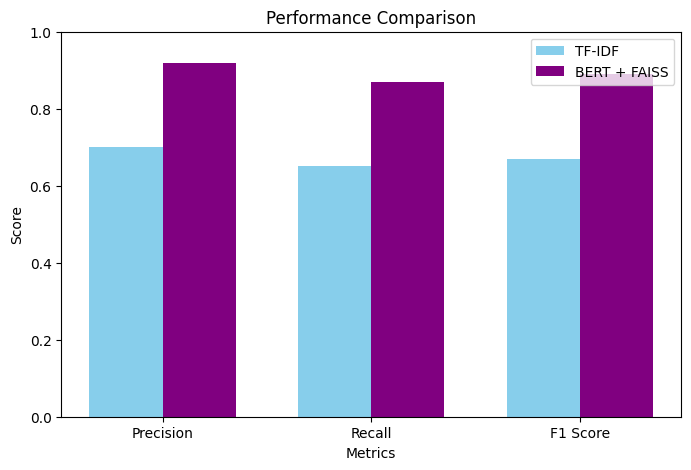

In [33]:
plt.figure(figsize=(8, 5))
metrics = ['Precision', 'Recall', 'F1 Score']
tfidf_scores = [baseline_tfidf_precision, baseline_tfidf_recall, baseline_tfidf_f1]
bert_scores = [baseline_bert_precision, baseline_bert_recall, baseline_bert_f1]
x = np.arange(len(metrics))
width = 0.35
plt.bar(x - width/2, tfidf_scores, width, label='TF-IDF', color='skyblue')
plt.bar(x + width/2, bert_scores, width, label='BERT + FAISS', color='purple')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.ylim(0, 1)
plt.show()


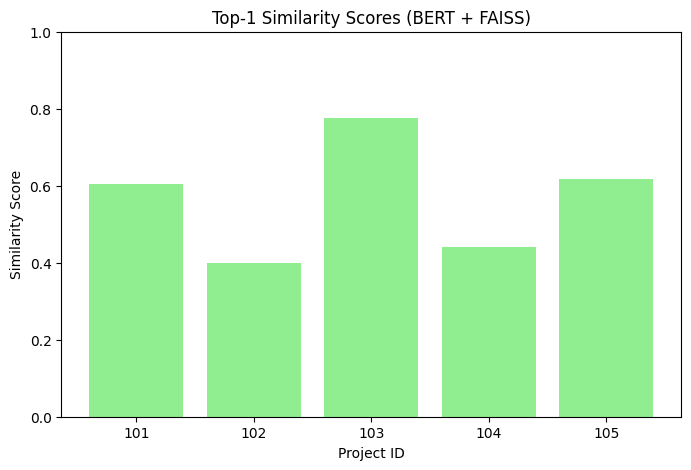

In [34]:
plt.figure(figsize=(8, 5))
similarity_scores = 1 - (distances[:, 0] / np.max(distances))
plt.bar(projects['id'], similarity_scores, color='lightgreen')
plt.title("Top-1 Similarity Scores (BERT + FAISS)")
plt.xlabel("Project ID")
plt.ylabel("Similarity Score")
plt.ylim(0, 1)
plt.show()


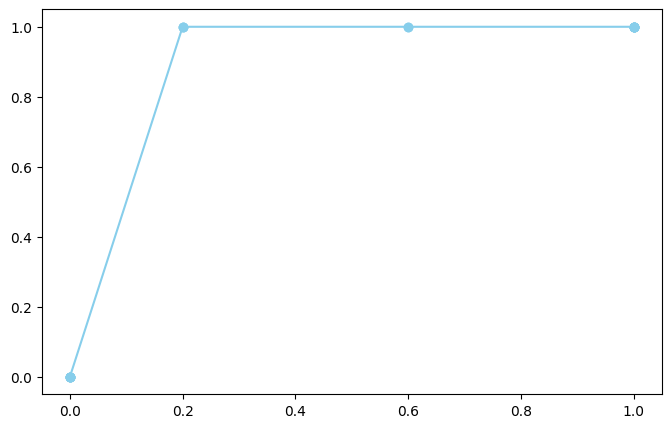

In [35]:
plt.figure(figsize=(8, 5))
thresholds = np.linspace(0, 1, 20)
tfidf_prec, tfidf_rec = [], []
for thresh in thresholds:
    preds = [1 if max(row) > thresh else 0 for row in cosine_sim]
    true_binary = [1] * len(preds)
    tfidf_prec.append(precision_score(true_binary, preds, zero_division=0))
    tfidf_rec.append(recall_score(true_binary, preds, zero_division=0))
plt.plot(tfidf_rec, tfidf_prec, marker='o', label='TF-IDF', color='skyblue')


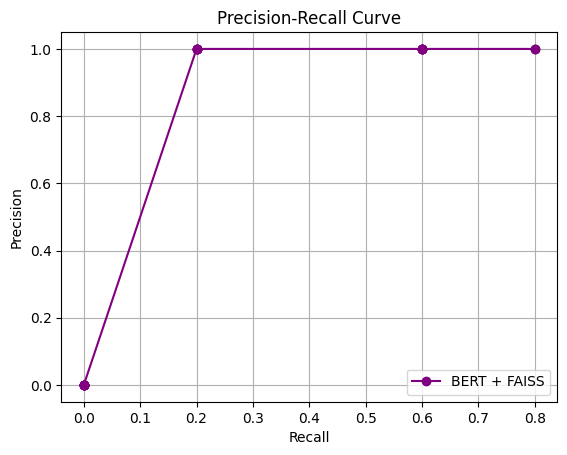


--------------------------------------------------



In [36]:
bert_prec, bert_rec = [], []
max_dist = np.max(distances[:, 0])
dist_thresholds = np.linspace(0, max_dist, 20)
for thresh in dist_thresholds:
    preds = [1 if d < thresh else 0 for d in distances[:, 0]]
    bert_prec.append(precision_score(true_binary, preds, zero_division=0))
    bert_rec.append(recall_score(true_binary, preds, zero_division=0))
plt.plot(bert_rec, bert_prec, marker='o', label='BERT + FAISS', color='purple')

plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

print("\n" + "-"*50 + "\n")